# Prediksi Harga Rumah California
Eksperimen regresi prediksi harga rumah menggunakan algoritma XGBoost.

## 1. Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

## 2. Load Data

In [4]:
data_housing = pd.read_csv("housing.csv")
data_housing

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


## 3. Cek Missing Value

In [9]:
#Cek ukuran data
print("Ukuran Data:", data_housing.shape)

#missing value
print("\nJumlah Data Kosong di Tiap Kolom:")
print(data_housing.isnull().sum())


Ukuran Data: (20640, 9)

Jumlah Data Kosong di Tiap Kolom:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


## 4. EDA (Grafik Korelasi)

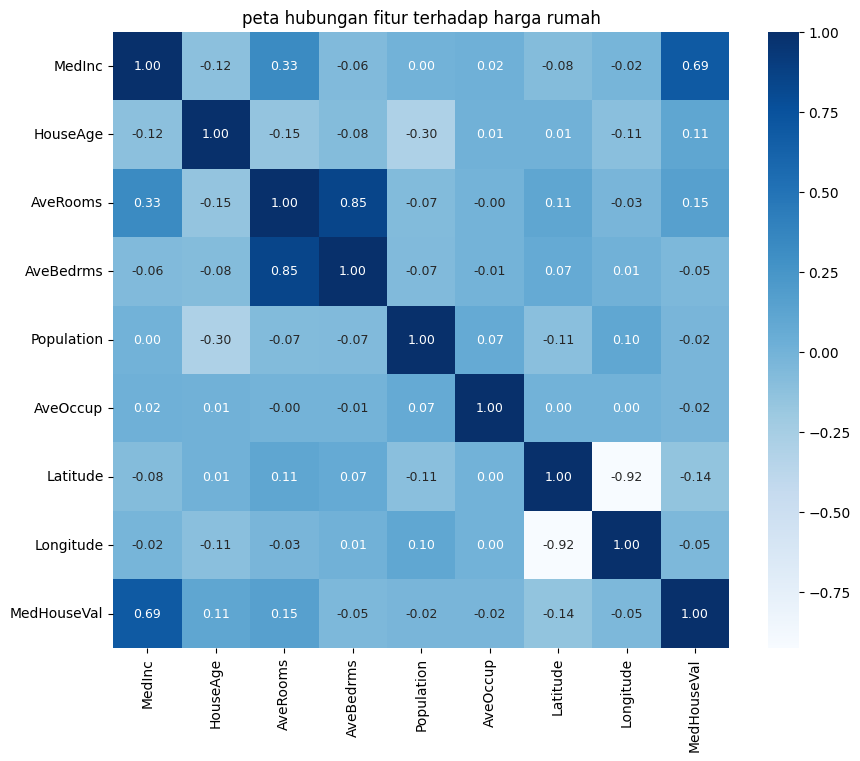

In [31]:
#membuta grafik korelasi antar kolom
korelasi = data_housing.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(korelasi, cbar=True, square= True, fmt='.2f', annot=True, annot_kws= {'size': 9}, cmap='Blues')
plt.title("peta hubungan fitur terhadap harga rumah")
plt.show()

## 5. Pisahkan Fitur & Target

In [36]:
#memisaihkan kolom target
X = data_housing.drop(columns='MedHouseVal', axis=1)

#menampilkan selain target
y = data_housing['MedHouseVal']

print("Total data:", X.shape)
print("Total data tanpa y :", y.shape)

Total data: (20640, 8)
Total data tanpa y : (20640,)


## 6. Train Test Split

In [ ]:
#membagi data latih dan uji
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=2)

print("Total Data Rumah :", X.shape)
print("Data Rumah Latih :", X_train.shape)
print("Data Rumah Uji   :", X_test.shape)


Total Data Rumah : (20640, 8)
Data Rumah Latih : (16512, 8)
Data Rumah Uji   : (4128, 8)


## 7. Training Model (XGBoost)

In [44]:
#membuat model
model = XGBRegressor()

model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## 8. Evaluasi Model

In [46]:
#evaluasi mode

#data latih
prediksi_latih = model.predict(X_train)
r2_latih = metrics.r2_score(y_train, prediksi_latih)
mae_latih = metrics.mean_absolute_error(y_train, prediksi_latih)
print("NILAI DATA LATIH")
print("R-squared Score :", round(r2_latih, 4))
print("MAE (Rata-rata Meleset) :", round(mae_latih, 4))

#data uji
prediksi_uji = model.predict(X_test)
r2_uji = metrics.r2_score(y_test, prediksi_uji)
mae_uji = metrics.mean_absolute_error(y_test, prediksi_uji)
print("\nNILAI DATA UJI")
print("R-squared Score :", round(r2_uji, 4))
print("MAE (Rata-rata Meleset) :", round(mae_uji, 4))


NILAI DATA LATIH
R-squared Score : 0.9437
MAE (Rata-rata Meleset) : 0.1934

NILAI DATA UJI
R-squared Score : 0.8338
MAE (Rata-rata Meleset) : 0.3109


## 9. Visualisasi Prediksi vs Asli

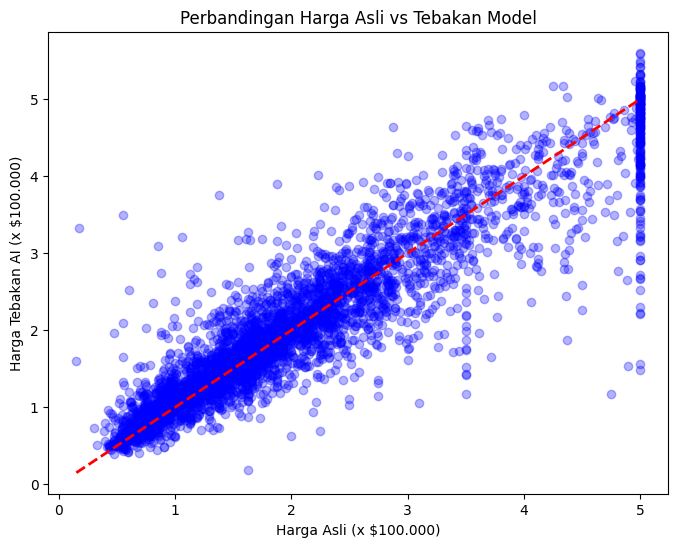

In [48]:
#grafik scatter plot

#titik sebaran harga asli vs prediksi
plt.figure(figsize=(8, 6))
plt.scatter(y_test, prediksi_uji, color='blue', alpha=0.3)

#garis merah diagonal
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2)
plt.xlabel("Harga Asli (x $100.000)")
plt.ylabel("Harga Tebakan AI (x $100.000)")
plt.title("Perbandingan Harga Asli vs Tebakan Model")
plt.show()


## 10. Taksiran Harga Data Baru

In [ ]:
#menaksir harga rumah baru 
data_rumah_baru = (8.3252, 41.0, 6.984127, 1.023810, 322.0, 2.555556, 37.88, -122.23)

data_array = np.asarray(data_rumah_baru)

data_siap = data_array.reshape(1, -1)

taksiran_harga = model.predict(data_siap)

#konversi dollar ke rupiah
harga_dollar = taksiran_harga[0] * 100000
harga_rupiah = harga_dollar * 16000


print("HASIL TAKSIRAN HARGA PROPERTI")
print(f"Skor Model     : {taksiran_harga[0]:.3f}")
print(f"Taksiran Harga : ${harga_dollar:,.2f} USD")
print(f"Setara Rupiah  : Rp {harga_rupiah:,.2f}")

HASIL TAKSIRAN HARGA PROPERTI
Skor Model     : 4.300
Taksiran Harga : $430,008.66 USD
Setara Rupiah  : Rp 6,880,138,752.00
